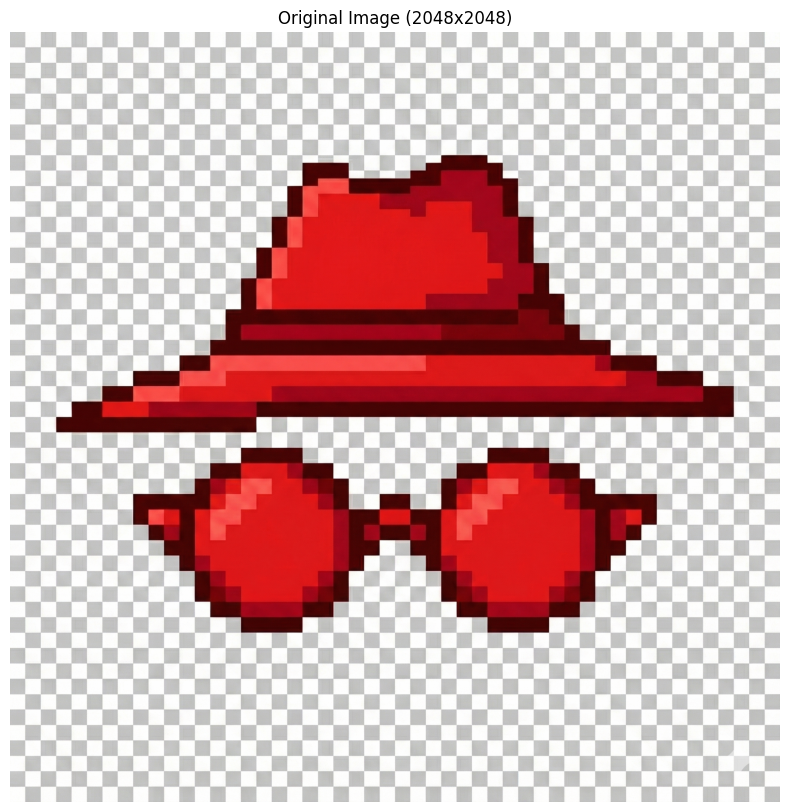

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from skimage.color import rgb2lab, lab2rgb
import knarrow
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the image
image_path = "terra-incognita.png"
img = Image.open(image_path).convert("RGB")
img_arr = np.array(img)

# Display the original image
plt.figure(figsize=(10, 10))
plt.imshow(img_arr)
plt.title("Original Image (2048x2048)")
plt.axis('off')
plt.show()


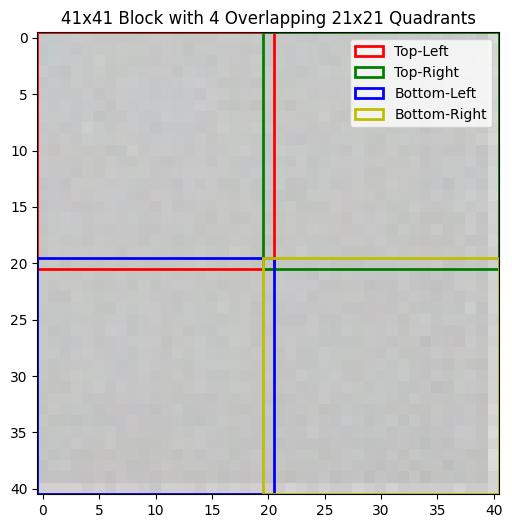

In [2]:
# Visualization of the 41x41 block and its four 21x21 overlapping quadrants
block = img_arr[0:41, 0:41]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(block)

# Draw the 4 quadrants
rects = [
    patches.Rectangle((-0.5, -0.5), 21, 21, linewidth=2, edgecolor='r', facecolor='none', label='Top-Left'),
    patches.Rectangle((19.5, -0.5), 21, 21, linewidth=2, edgecolor='g', facecolor='none', label='Top-Right'),
    patches.Rectangle((-0.5, 19.5), 21, 21, linewidth=2, edgecolor='b', facecolor='none', label='Bottom-Left'),
    patches.Rectangle((19.5, 19.5), 21, 21, linewidth=2, edgecolor='y', facecolor='none', label='Bottom-Right')
]

for rect in rects:
    ax.add_patch(rect)

ax.legend(loc='upper right')
plt.title("41x41 Block with 4 Overlapping 21x21 Quadrants")
plt.show()


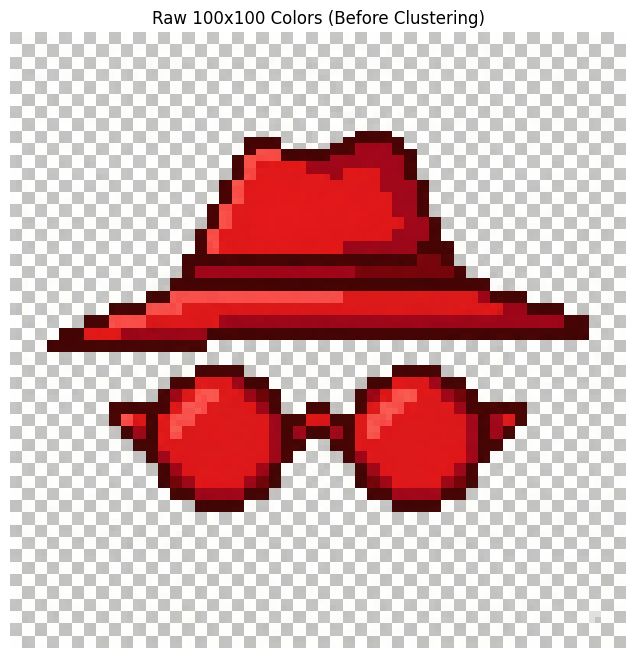

In [3]:
# Apply the extracting algorithm
# We extract a 50x50 grid of 41x41 blocks. For each block, we get 4 quadrant pixels.
# The resulting image will be exactly 100x100 pixels.
height, width, _ = img_arr.shape
grid_size = 50
output_size = grid_size * 2  # 100x100
block_size = 41

averaged_colors = np.zeros((output_size, output_size, 3))

for r in range(grid_size):
    for c in range(grid_size):
        r_start = r * block_size
        c_start = c * block_size
        r_end = min(r_start + block_size, height)
        c_end = min(c_start + block_size, width)
        
        patch = img_arr[r_start:r_end, c_start:c_end]
        
        # We need at least 21x21 to do the 4 quadrants properly. 
        # If the patch is truncated, we adapt.
        ph, pw, _ = patch.shape
        qh = min(21, ph)
        qw = min(21, pw)
        
        q1 = patch[0:qh, 0:qw]
        q2 = patch[0:qh, -qw:]
        q3 = patch[-qh:, 0:qw]
        q4 = patch[-qh:, -qw:]
        
        m1 = np.median(q1, axis=(0,1))
        m2 = np.median(q2, axis=(0,1))
        m3 = np.median(q3, axis=(0,1))
        m4 = np.median(q4, axis=(0,1))
        
        averaged_colors[r * 2, c * 2] = m1
        averaged_colors[r * 2, c * 2 + 1] = m2
        averaged_colors[r * 2 + 1, c * 2] = m3
        averaged_colors[r * 2 + 1, c * 2 + 1] = m4

X = averaged_colors.reshape(-1, 3)

# Add explicit assertions to satisfy our constraints
assert averaged_colors.shape == (100, 100, 3), f"Expected averaged_colors to be (100, 100, 3), got {averaged_colors.shape}"
assert X.shape[0] == 10000, f"Expected 10,000 pixels for clustering, got {X.shape[0]}"

# Display the raw 100x100 averaged colors
plt.figure(figsize=(8, 8))
plt.imshow(averaged_colors.astype(np.uint8))
plt.title("Raw 100x100 Colors (Before Clustering)")
plt.axis('off')
plt.show()


In [4]:
# Create an interactive 3D scatter plot of ALL 10,000 raw RGB colors using Plotly
import plotly.express as px
import pandas as pd

print("Generating Interactive 3D Scatter Plot for ALL 10,000 colors...")
df_all_3d = pd.DataFrame(X, columns=['Red', 'Green', 'Blue'])
df_all_3d['color_hex'] = ['#%02x%02x%02x' % tuple(c) for c in X.astype(int)]

fig = px.scatter_3d(
    df_all_3d, x='Red', y='Green', z='Blue',
    color='color_hex',
    color_discrete_map='identity',
    title="Interactive 3D Scatter Plot of All 10,000 Raw RGB Colors",
    opacity=0.3
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=800, scene=dict(xaxis=dict(range=[0, 255]), yaxis=dict(range=[0, 255]), zaxis=dict(range=[0, 255]), aspectmode='cube'))
fig.show()


Generating Interactive 3D Scatter Plot for ALL 10,000 colors...


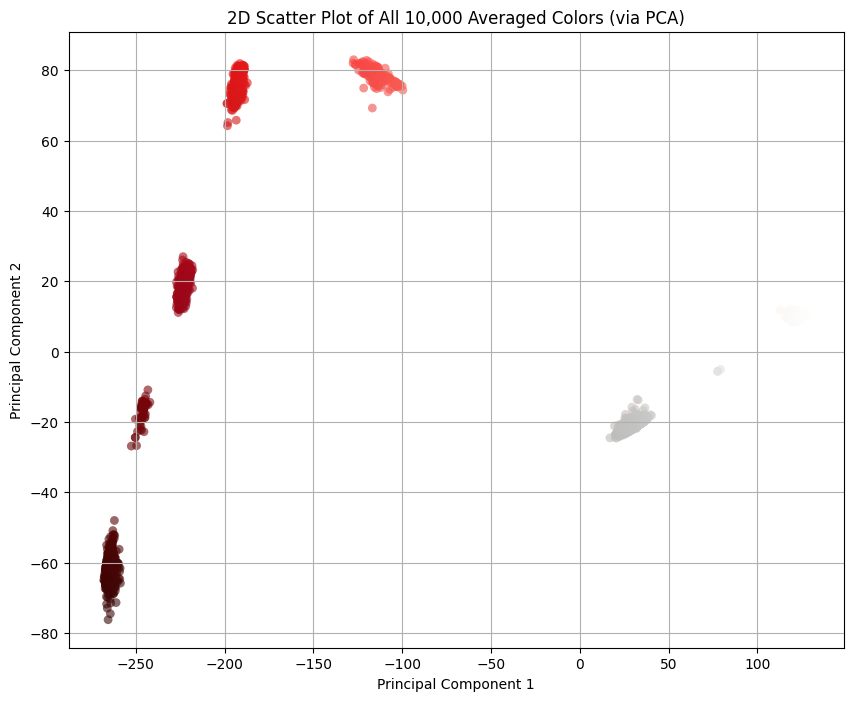

In [5]:
# Visualize all 10,000 averaged colors on a 2D graph using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
# Normalize colors to [0, 1] for matplotlib scatter
scatter_colors = X / 255.0

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=scatter_colors, alpha=0.6, edgecolors='none', s=40)
plt.title("2D Scatter Plot of All 10,000 Averaged Colors (via PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


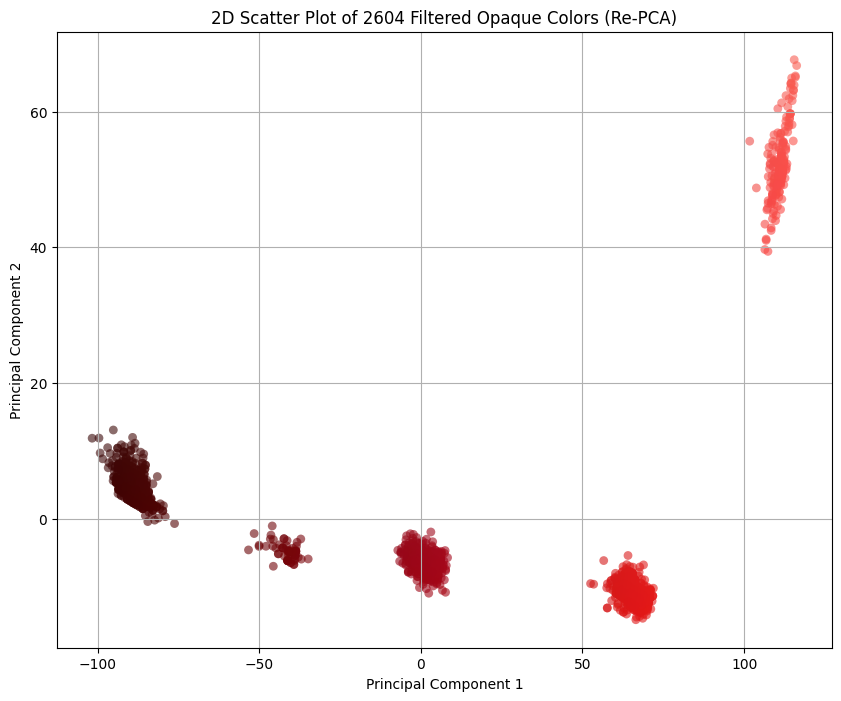

In [6]:
# Filter out transparent background regions using PCA explicitly
# The visual clearly shows PC1 > -50 separates the white/gray background.
transparent_mask = X_pca[:, 0] > -50
opaque_mask = ~transparent_mask

X_filtered = X[opaque_mask]

# Re-PCA on just the opaque colors to visualize the remaining clusters better
pca_filtered = PCA(n_components=2)
X_filtered_pca = pca_filtered.fit_transform(X_filtered)

plt.figure(figsize=(10, 8))
scatter_colors_filtered = X_filtered / 255.0

plt.scatter(X_filtered_pca[:, 0], X_filtered_pca[:, 1], c=scatter_colors_filtered, alpha=0.6, edgecolors='none', s=40)
plt.title(f"2D Scatter Plot of {len(X_filtered)} Filtered Opaque Colors (Re-PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


Calculating PCA on CIELAB coordinates...


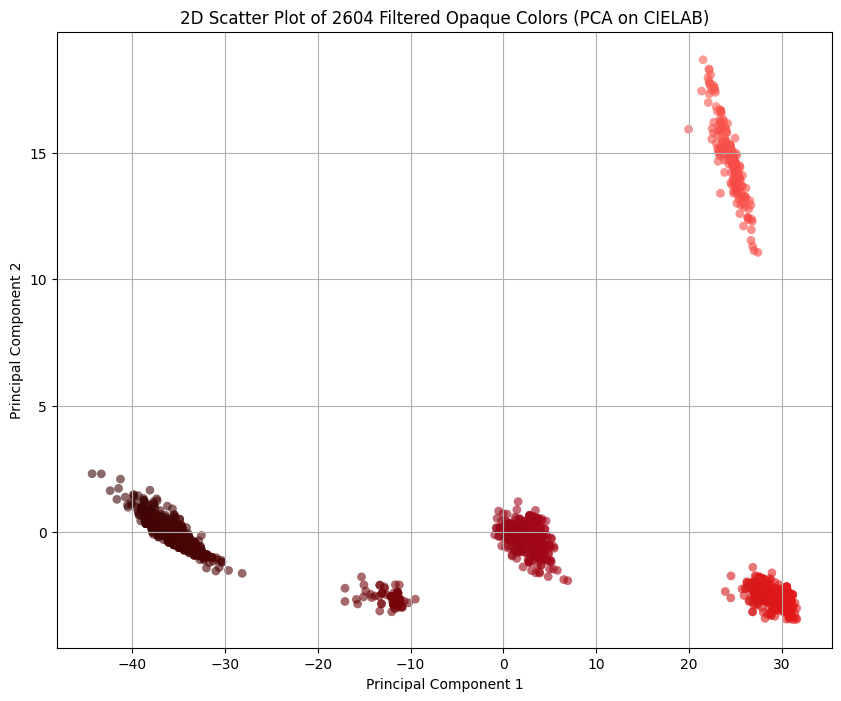

Calculating t-SNE embedding in LAB space (this may take a few seconds)...


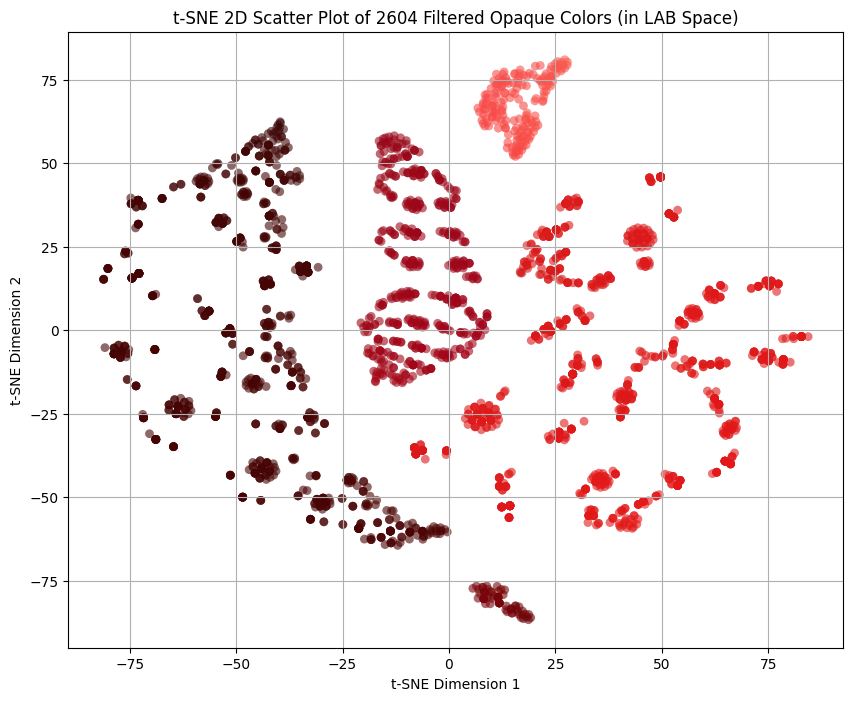

In [7]:
# Convert opaque RGB pixels to LAB color space for perceptually uniform clustering
X_filtered_img = X_filtered.reshape(-1, 1, 3) / 255.0  # normalized RGB image slice
X_filtered_lab = rgb2lab(X_filtered_img).reshape(-1, 3)

# Visualize all opaque colors on a 2D graph using PCA on CIELAB coordinates
print("Calculating PCA on CIELAB coordinates...")
pca_lab = PCA(n_components=2)
X_filtered_pca_lab = pca_lab.fit_transform(X_filtered_lab)

plt.figure(figsize=(10, 8))
# Use the same scatter_colors_filtered as before (RGB colors normalized to [0, 1])
plt.scatter(X_filtered_pca_lab[:, 0], X_filtered_pca_lab[:, 1], c=scatter_colors_filtered, alpha=0.6, edgecolors='none', s=40)
plt.title(f"2D Scatter Plot of {len(X_filtered)} Filtered Opaque Colors (PCA on CIELAB)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Apply t-SNE on the opaque colors in CIELAB space for a better non-linear 2D visualization
from sklearn.manifold import TSNE

print("Calculating t-SNE embedding in LAB space (this may take a few seconds)...")
tsne = TSNE(n_components=2, random_state=42)
X_filtered_tsne = tsne.fit_transform(X_filtered_lab)

plt.figure(figsize=(10, 8))
# We still color the points with their RGB values
plt.scatter(X_filtered_tsne[:, 0], X_filtered_tsne[:, 1], c=scatter_colors_filtered, alpha=0.6, edgecolors='none', s=40)
plt.title(f"t-SNE 2D Scatter Plot of {len(X_filtered)} Filtered Opaque Colors (in LAB Space)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()


In [8]:
# Create an interactive 3D scatter plot of the raw RGB colors using Plotly
import plotly.express as px
import pandas as pd

print("Generating Interactive 3D Scatter Plot...")
df_3d = pd.DataFrame(X_filtered, columns=['Red', 'Green', 'Blue'])
df_3d['color_hex'] = ['#%02x%02x%02x' % tuple(c) for c in X_filtered.astype(int)]

fig = px.scatter_3d(
    df_3d, x='Red', y='Green', z='Blue',
    color='color_hex',
    color_discrete_map='identity',
    title=f"Interactive 3D Scatter Plot of {len(X_filtered)} Opaque RGB Colors",
    opacity=0.7
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(height=800, scene=dict(xaxis=dict(range=[0, 255]), yaxis=dict(range=[0, 255]), zaxis=dict(range=[0, 255]), aspectmode='cube'))
fig.show()


Generating Interactive 3D Scatter Plot...


Running K-Means 100 times per k...


Selected Optimal k = 5 (via knarrow 'all' voting)


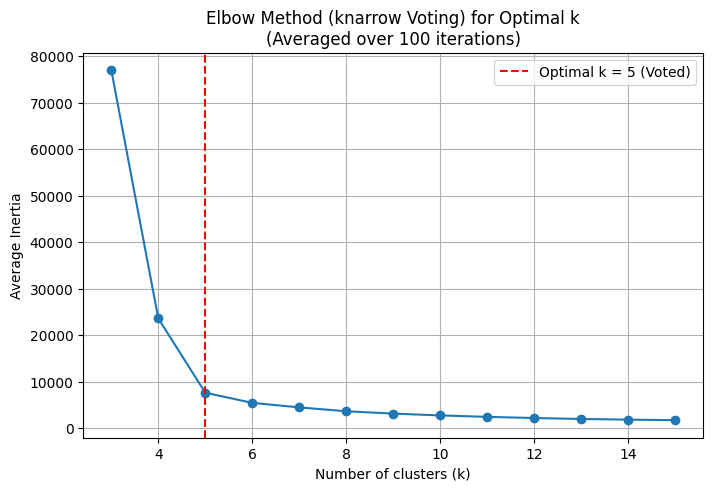

In [9]:
# Calculate average inertias for k=3..15 using N=100 iterations per k
# Note: K is processed ONLY on the opaque pixels (in LAB space)

k_values = list(range(3, 16))
num_iterations = 100
inertias = []

print(f"Running K-Means {num_iterations} times per k...")
for k in k_values:
    avg_inertia = 0.0
    for dummy in range(num_iterations):
        kmeans = KMeans(n_clusters=k, n_init=1)
        kmeans.fit(X_filtered_lab)
        avg_inertia += kmeans.inertia_
    inertias.append(avg_inertia / num_iterations)

# Use knarrow's built-in "all" voting mechanism
optimal_idx = knarrow.find_knee(k_values, inertias, method="all")
optimal_k = k_values[optimal_idx]

print(f"Selected Optimal k = {optimal_k} (via knarrow 'all' voting)")

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k} (Voted)')
plt.title(f"Elbow Method (knarrow Voting) for Optimal k\n(Averaged over {num_iterations} iterations)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Inertia")
plt.legend()
plt.grid(True)
plt.show()



--- Generating Map for k = 3 ---


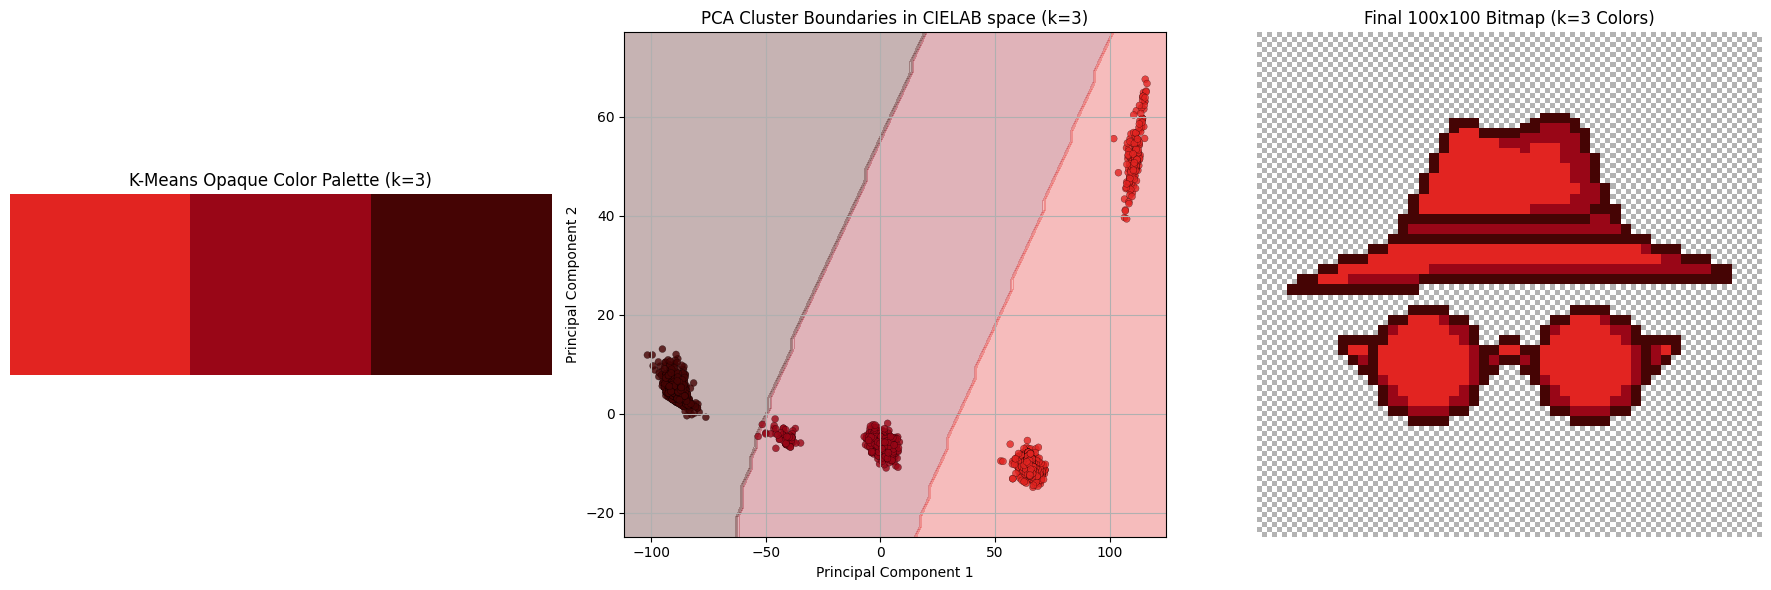

Saved tightly to rasterized_map_3colors_1777825848.png

--- Generating Map for k = 4 ---


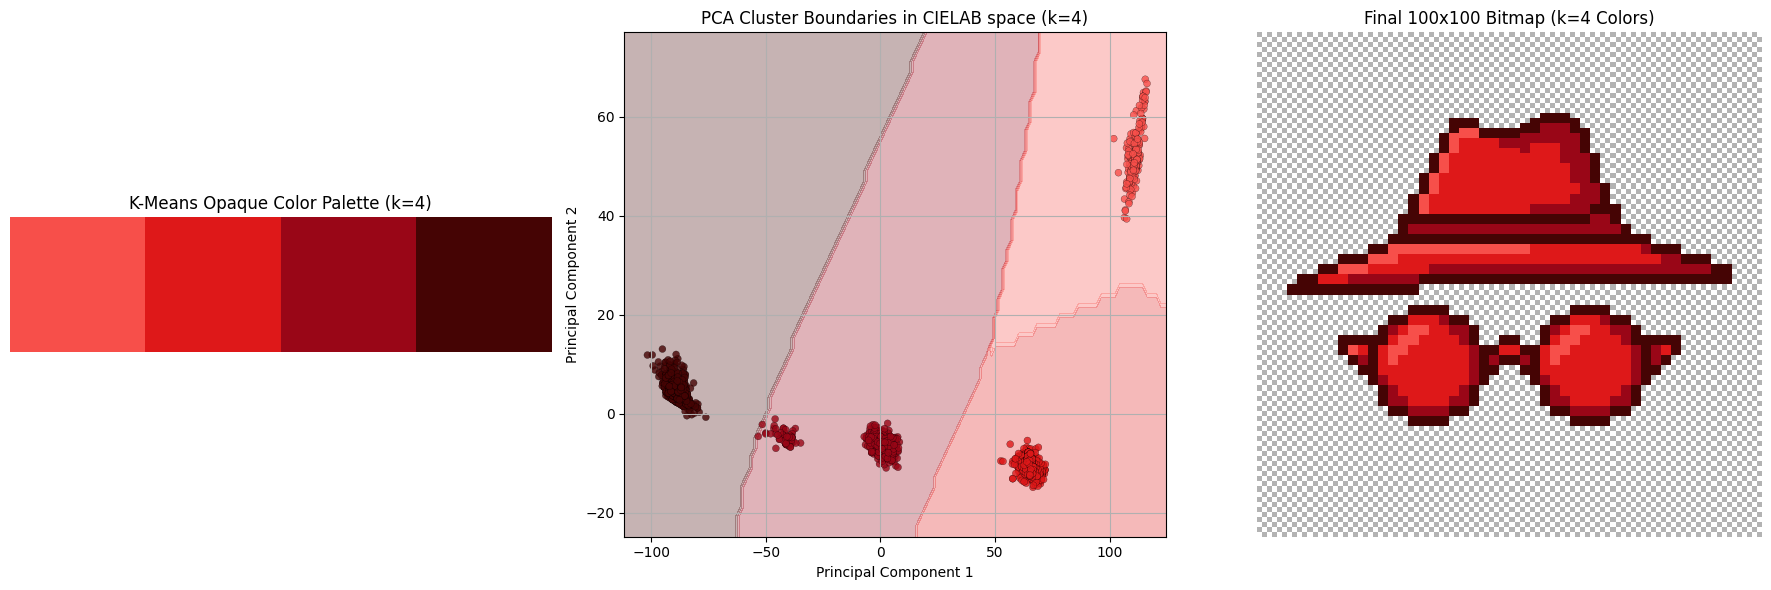

Saved tightly to rasterized_map_4colors_1777825848.png

--- Generating Map for k = 5 ---


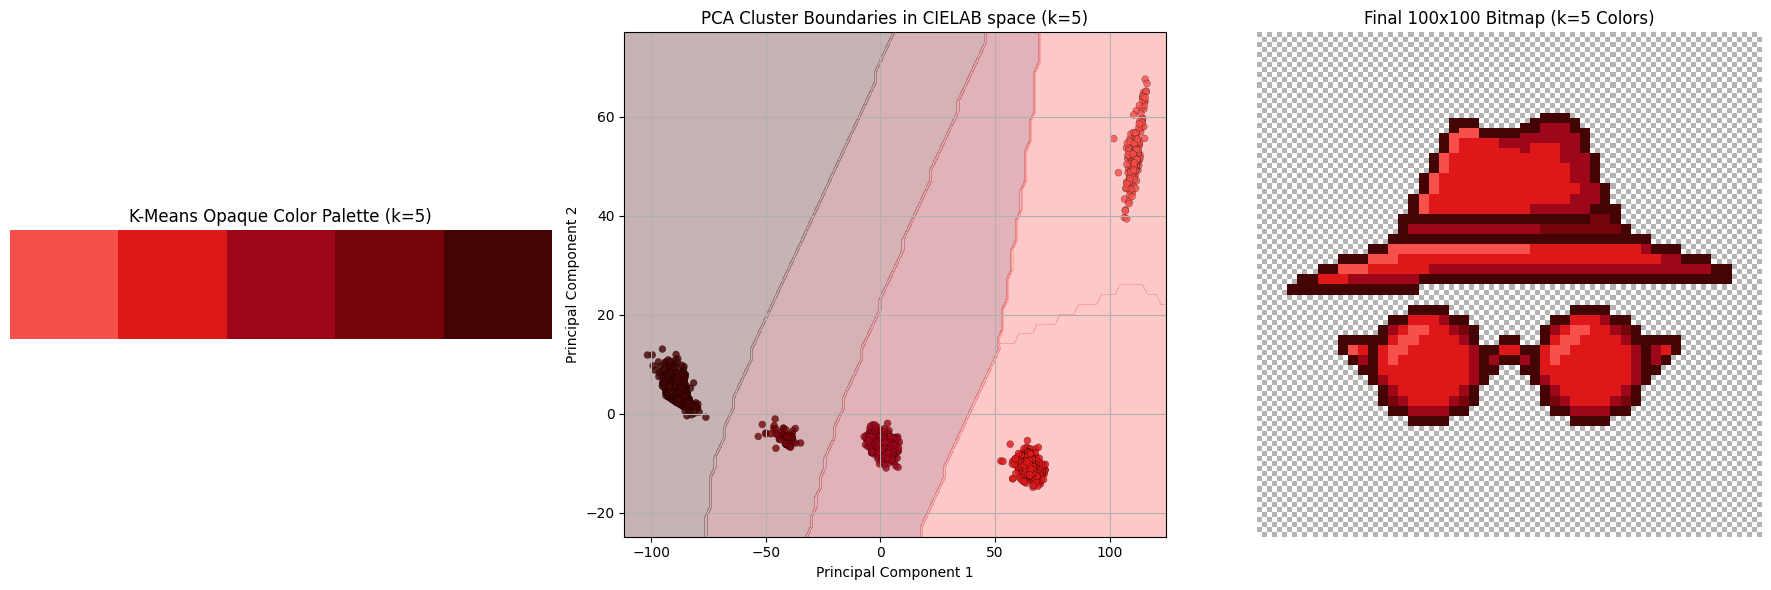

Saved tightly to rasterized_map_5colors_1777825848.png

--- Generating Map for k = 6 ---


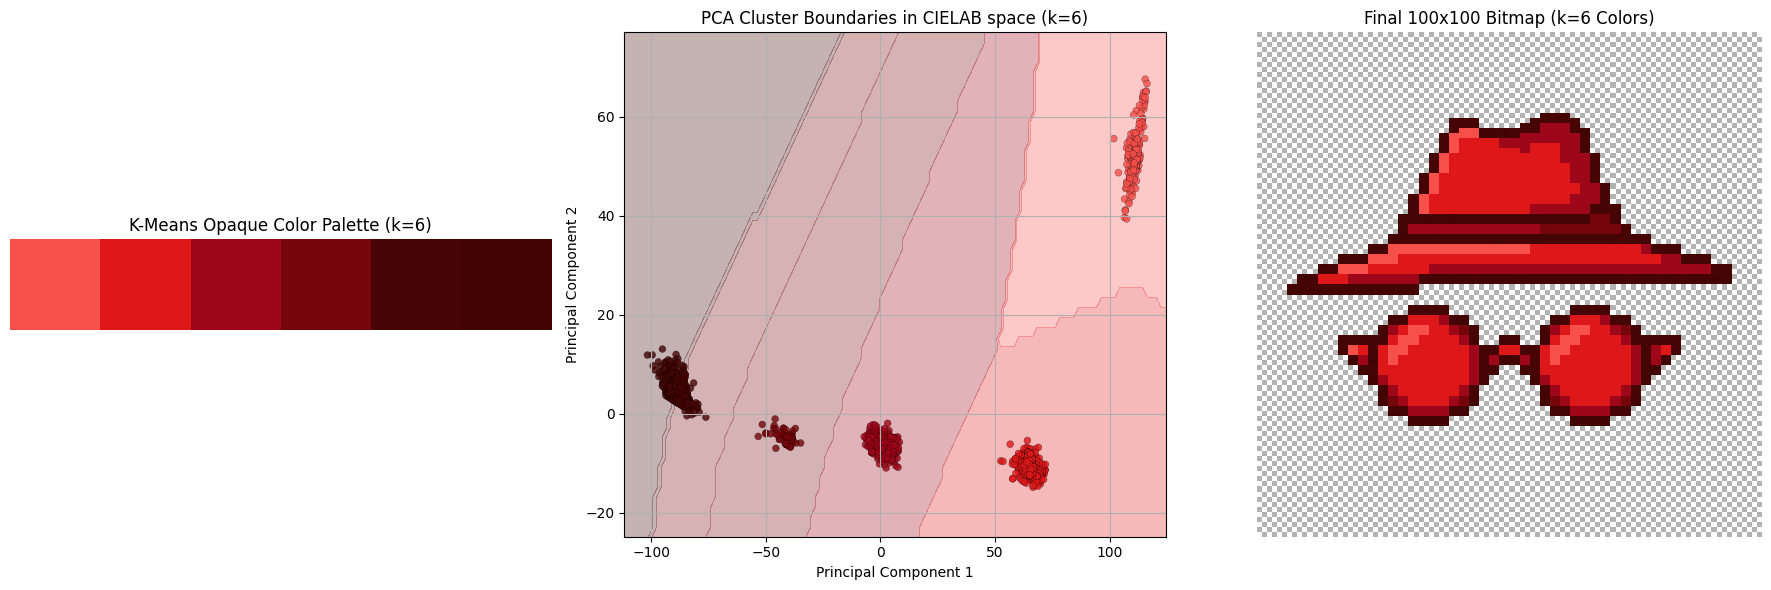

Saved tightly to rasterized_map_6colors_1777825848.png

--- Generating Map for k = 7 ---


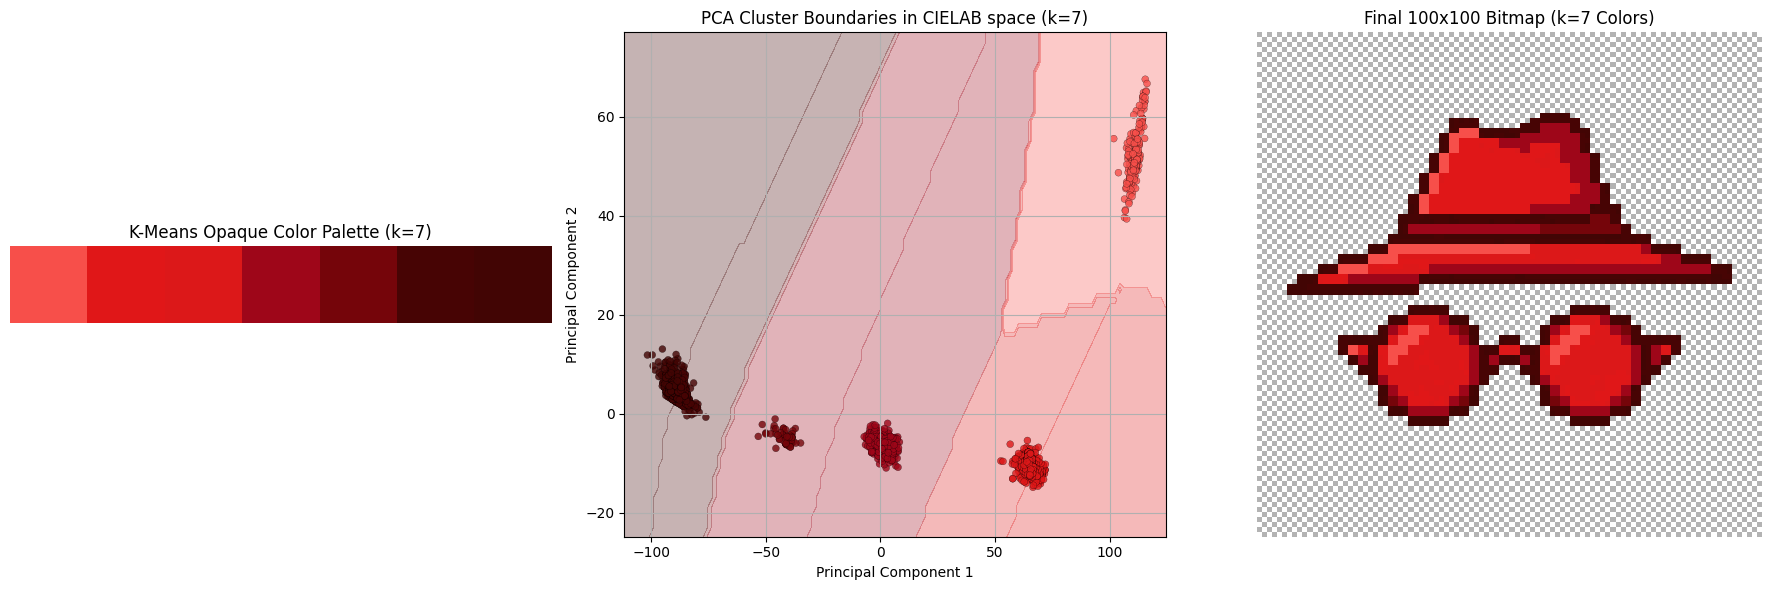

Saved tightly to rasterized_map_7colors_1777825848.png

--- Generating Map for k = 8 ---


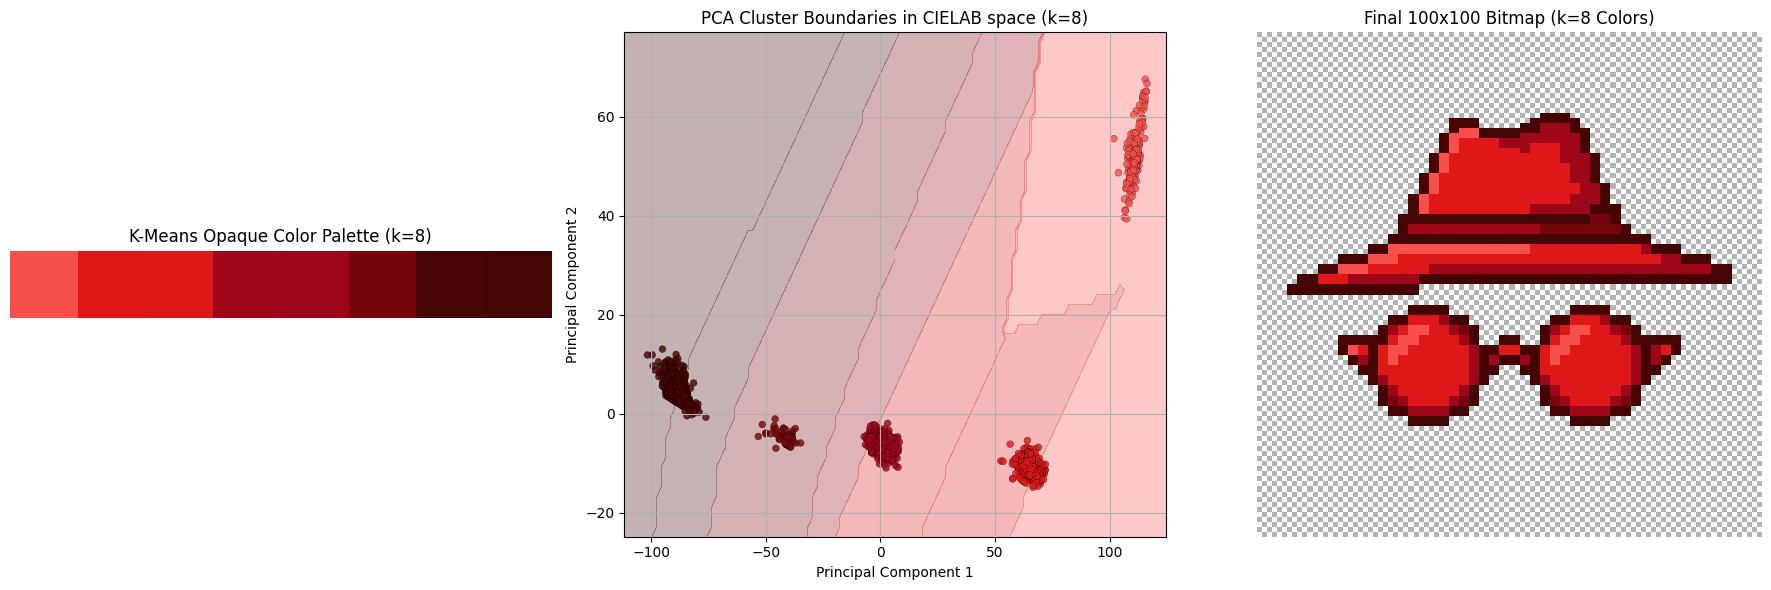

Saved tightly to rasterized_map_8colors_1777825848.png


In [10]:
timestamp = int(time.time())

final_k5_centers = None
final_k5_labels = None

for k in range(3, 9):
    print(f"\n--- Generating Map for k = {k} ---")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_filtered_lab)
    centers_lab = kmeans.cluster_centers_

    # Sort centers from lightest (highest L) to darkest (lowest L) in LAB space
    sort_indices = np.argsort(-centers_lab[:, 0])
    centers_lab = centers_lab[sort_indices]

    # Remap K-Means labels to match the newly sorted centers
    inverse_map = np.zeros_like(sort_indices)
    for new_idx, old_idx in enumerate(sort_indices):
        inverse_map[old_idx] = new_idx
    
    labels = inverse_map[labels]

    # Convert LAB centers back to RGB for visualization and map making
    centers_lab_img = centers_lab.reshape(-1, 1, 3)
    centers_rgb_img = lab2rgb(centers_lab_img)
    centers = (centers_rgb_img.reshape(-1, 3) * 255).astype(np.uint8)

    # Set up the combined figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Visualize the color palette
    axes[0].imshow([centers])
    axes[0].set_title(f"K-Means Opaque Color Palette (k={k})")
    axes[0].axis('off')

    # 2. Create a meshgrid covering the PCA space to visualize decision boundaries
    from matplotlib.colors import ListedColormap
    h = 2.0  # step size
    x_min, x_max = X_filtered_pca[:, 0].min() - 10, X_filtered_pca[:, 0].max() + 10
    y_min, y_max = X_filtered_pca[:, 1].min() - 10, X_filtered_pca[:, 1].max() + 10
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Inverse PCA back to RGB, then normalize and jump to LAB space
    grid_pca = np.c_[xx.ravel(), yy.ravel()]
    grid_rgb = pca_filtered.inverse_transform(grid_pca)
    grid_rgb_clipped = np.clip(grid_rgb, 0, 255) / 255.0
    grid_lab = rgb2lab(grid_rgb_clipped.reshape(-1, 1, 3)).reshape(-1, 3)
    
    # Predict the grid points, remap their color indexes
    Z = kmeans.predict(grid_lab)
    Z = inverse_map[Z] 
    Z = Z.reshape(xx.shape)
    
    # Draw contour
    cmap_custom = ListedColormap(centers / 255.0)
    axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_custom)
    
    # Plot actual points colored by their mapped colors
    scatter_c = [centers[lbl]/255.0 for lbl in labels]
    axes[1].scatter(X_filtered_pca[:, 0], X_filtered_pca[:, 1], c=scatter_c, alpha=0.8, edgecolors='k', s=25, linewidth=0.2)
    axes[1].set_title(f"PCA Cluster Boundaries in CIELAB space (k={k})")
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")
    axes[1].grid(True)

    # 3. Reconstruct the image with an alpha channel
    final_image = np.zeros((output_size, output_size, 4), dtype=np.uint8)

    opaque_idx = 0
    for i in range(output_size * output_size):
        r = i // output_size
        c = i % output_size
        
        if transparent_mask[i]:
            # Transparent
            final_image[r, c] = [0, 0, 0, 0]
        else:
            # Map back from K-Means prediction to original location
            cluster_idx = labels[opaque_idx]
            color = centers[cluster_idx].astype(np.uint8)
            final_image[r, c] = [color[0], color[1], color[2], 255]
            opaque_idx += 1

    # Setup a checkerboard background so transparency is visible
    checkerboard = np.indices((output_size, output_size)).sum(axis=0) % 2
    axes[2].imshow(checkerboard, cmap='gray', alpha=0.3)
    axes[2].imshow(final_image)
    axes[2].set_title(f"Final 100x100 Bitmap (k={k} Colors)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Save as lossless PNG
    filename = f"rasterized_map_{k}colors_{timestamp}.png"
    out_img = Image.fromarray(final_image, 'RGBA')
    out_img.save(filename)
    print(f"Saved tightly to {filename}")

    if k == 5:
        final_k5_centers = centers
        final_k5_labels = labels


--- Comparing k=4 vs k=5 ---


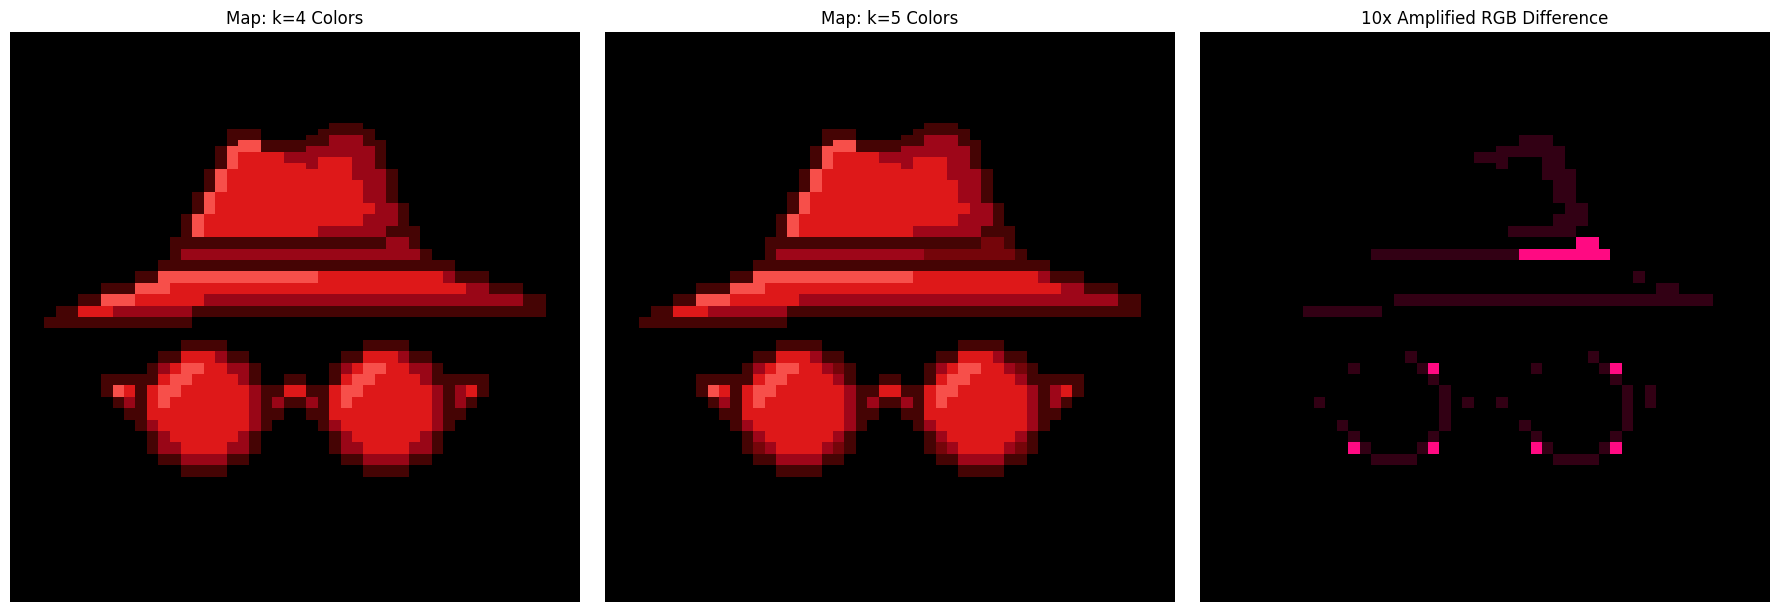


--- Final Chosen k=5 RGB Colors (Lightest to Darkest) ---
Cluster 1: RGB [np.uint8(247), np.uint8(79), np.uint8(74)]
Cluster 2: RGB [np.uint8(222), np.uint8(24), np.uint8(25)]
Cluster 3: RGB [np.uint8(158), np.uint8(6), np.uint8(25)]
Cluster 4: RGB [np.uint8(117), np.uint8(5), np.uint8(10)]
Cluster 5: RGB [np.uint8(69), np.uint8(4), np.uint8(4)]


In [11]:
import os
from PIL import Image, ImageChops, ImageEnhance
import matplotlib.pyplot as plt

print("--- Comparing k=4 vs k=5 ---")
map_4_file = f"rasterized_map_4colors_{timestamp}.png"
map_5_file = f"rasterized_map_5colors_{timestamp}.png"

if not os.path.exists(map_4_file) or not os.path.exists(map_5_file):
    print("Could not find the generated images for k=4 and k=5!")
else:
    img4 = Image.open(map_4_file).convert("RGB")
    img5 = Image.open(map_5_file).convert("RGB")
    
    diff_img = ImageChops.difference(img4, img5)
    
    enhancer = ImageEnhance.Brightness(diff_img)
    diff_bright = enhancer.enhance(10.0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img4)
    axes[0].set_title("Map: k=4 Colors")
    axes[0].axis("off")
    
    axes[1].imshow(img5)
    axes[1].set_title("Map: k=5 Colors")
    axes[1].axis("off")
    
    axes[2].imshow(diff_bright)
    axes[2].set_title("10x Amplified RGB Difference")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

print("\n--- Final Chosen k=5 RGB Colors (Lightest to Darkest) ---")
if final_k5_centers is not None:
    for i, color in enumerate(final_k5_centers):
        print(f"Cluster {i+1}: RGB {list(color)}")
else:
    print("k=5 centers not found.")


In [12]:
# Save the optimal k=5 map as an Indexed Palette PNG (PNG-8)
print("\n--- Saving Indexed Palette PNG for k=5 ---")
if final_k5_centers is not None and final_k5_labels is not None:
    # 1. Construct the palette array
    # Index 0 will be our transparent background (0,0,0)
    # Indices 1-5 will be our K=5 colors
    palette = [0, 0, 0]
    for color in final_k5_centers:
        palette.extend(color.astype(int).tolist())
    
    # 2. Build the flat indexed image array
    indexed_data = np.zeros((output_size, output_size), dtype=np.uint8)
    opaque_idx = 0
    for i in range(output_size * output_size):
        r = i // output_size
        c = i % output_size
        if transparent_mask[i]:
            indexed_data[r, c] = 0
        else:
            indexed_data[r, c] = final_k5_labels[opaque_idx] + 1
            opaque_idx += 1
            
    # 3. Create a 'P' mode image
    paletted_img = Image.fromarray(indexed_data, mode='P')
    
    # 4. Inject the palette
    paletted_img.putpalette(palette)
    
    # 5. Save with transparency index 0
    indexed_filename = f"indexed_map_5colors_{timestamp}.png"
    paletted_img.save(indexed_filename, transparency=0, optimize=True)
    
    print(f"Successfully saved incredibly small Indexed PNG to {indexed_filename}")
else:
    print("k=5 state not found.")



--- Saving Indexed Palette PNG for k=5 ---
Successfully saved incredibly small Indexed PNG to indexed_map_5colors_1777825848.png



--- 16x16 Extracted Map Data ---


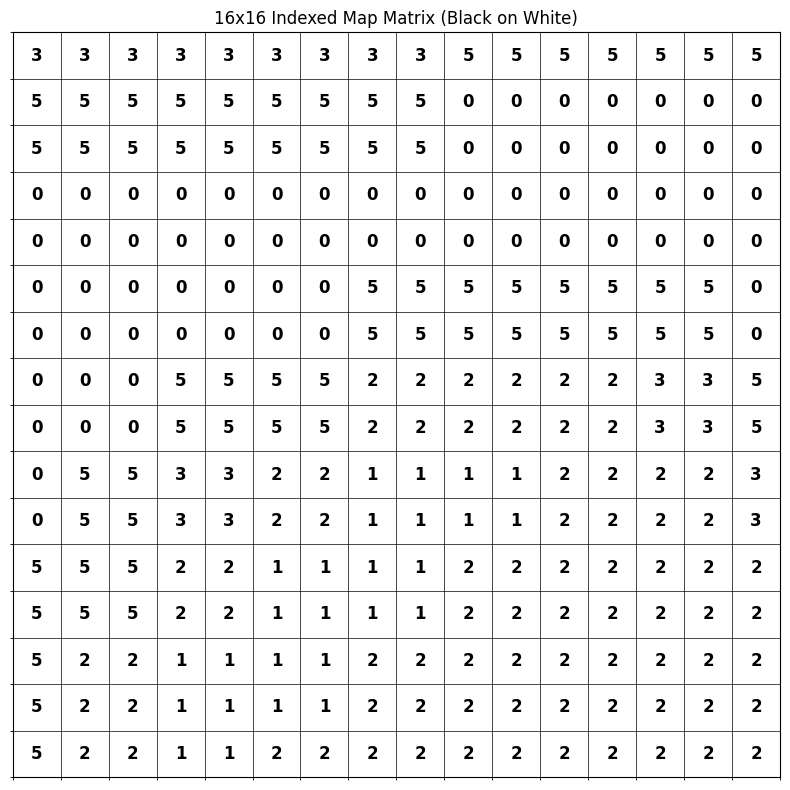

In [13]:
import matplotlib.pyplot as plt

print("\n--- 16x16 Extracted Map Data ---")
# Extracting 16x16 square starting from (23, 49)
if 'indexed_data' in locals():
    # Assuming (23, 49) refers to (col, row)
    row_start, col_start = 49, 23
    subset = indexed_data[row_start:row_start+16, col_start:col_start+16]
    
    # Display the 16x16 integer matrix using Matplotlib (Black on White)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('white')
    
    # We set the limits to encompass the 16x16 grid
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(15.5, -0.5) # Invert y to match image/matrix row ordering
    
    # Add text annotations in black
    for i in range(16):
        for j in range(16):
            val = subset[i, j]
            ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=12, fontweight='bold')
            
    # Add a clean grid to separate the cells
    ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    
    # Title and major ticks
    ax.set_title("16x16 Indexed Map Matrix (Black on White)")
    ax.set_xticks(range(16))
    ax.set_yticks(range(16))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which='major', length=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("indexed_data is not available.")
